# Session 18 — Model Validation & Resampling Techniques: K-Fold Cross-Validation, Stratified Sampling, Bias-Variance Trade-offs, and Automated Evaluation
---

### **Overview & Learning Objectives**
In this session, we investigate **Cross-Validation**—the foundational statistical methodology used to assess how the results of a statistical analysis will generalize to an independent dataset. A single train-test split (holdout validation) is notoriously vulnerable to sampling noise, sample ordering, and optimistic or pessimistic bias.

We systematically explore:
1. **$k$-Fold Cross-Validation Fundamentals**: Using `cross_val_score()` with **K-Nearest Neighbors (KNN)** on the Iris dataset to obtain an unbiased estimate of generalization accuracy.
2. **Multi-Fold Granular Evaluation ($10$-Fold CV)**: Running a 10-fold cross-validation with **Decision Trees** on a complex medical diagnostic benchmark (Breast Cancer Wisconsin), recording and analyzing the variance across individual test folds.
3. **Stratified Sampling Mechanics (`StratifiedKFold`)**: Deconstructing how stratified resampling preserves the exact class label distribution across every training and validation fold, contrasting it directly with standard unstratified `KFold`.
4. **Hyperparameter Stability of $k$ ($k \in \{3, 5, 10\}$)**: Evaluating the bias-variance trade-off of the number of folds ($k$) with a **Random Forest Classifier** on the Wine dataset, identifying which $k$ minimizes score variance ($\sigma$).
5. **AI-Assisted Function Engineering**: Designing, documenting, and testing a reusable, industrial-grade cross-validation pipeline function with automated validation, statistical confidence intervals, and visualization.

| Question | Core Topic | Primary Dataset Used | Core Scikit-Learn Class / Tool | Key Methodological Focus |
|:---|:---|:---|:---|:---|
| **Question 1** | Baseline 5-Fold Cross-Validation | Scikit-Learn Iris Dataset | `KNeighborsClassifier`, `cross_val_score` | Mean generalization accuracy & score dispersion |
| **Question 2** | 10-Fold CV & Fold-by-Fold Analysis | Breast Cancer Wisconsin Dataset | `DecisionTreeClassifier`, `cross_val_score` | High-variance base estimator stability across 10 folds |
| **Question 3** | Stratified vs. Standard K-Fold | Iris Dataset | `StratifiedKFold` vs. `KFold` | Class distribution preservation & prevention of zero-sample folds |
| **Question 4** | Fold Count Sensitivity ($k \in \{3, 5, 10\}$) | Wine Recognition Dataset | `RandomForestClassifier`, Standard Deviation ($\sigma$) | Empirical bias-variance trade-off in small sample sizes |
| **Question 5** | Reusable AI-Assisted CV Pipeline | Multi-Model Benchmark (Iris / Wine) | Generalized `evaluate_classifier_cv` Function | Production-ready tooling, type hinting, and statistical reporting |


---
## Question 1
**Load the Iris dataset using scikit-learn and use `cross_val_score()` with a `KNeighborsClassifier` to compute the average accuracy using 5-fold cross-validation.**

---

### 1. Conceptual Background & Mathematical Foundation

In a standard holdout train-test split, a model's score can vary drastically depending on which samples happen to land in the test partition. **$k$-Fold Cross-Validation** mitigates this sampling bias by partitioning the entire dataset $\mathcal{D}$ of $N$ observations into $k$ mutually exclusive, approximately equal-sized subsets:
$$\mathcal{D} = \mathcal{D}_1 \cup \mathcal{D}_2 \cup \dots \cup \mathcal{D}_k$$

#### **Algorithmic Workflow**:
1. For each iteration $i \in \{1, 2, \dots, k\}$:
   - The $i$-th fold $\mathcal{D}_i$ is held out as the **validation set**.
   - The remaining $k - 1$ folds $\mathcal{D}_{(-i)} = \bigcup_{j \neq i} \mathcal{D}_j$ serve as the **training set**.
   - The estimator $\hat{f}_i$ is trained on $\mathcal{D}_{(-i)}$ and evaluated on $\mathcal{D}_i$, yielding performance metric $S_i$.
2. The final cross-validated score is the sample mean across all $k$ folds:
   $$\bar{S} = \frac{1}{k} \sum_{i=1}^k S_i$$
3. The standard error of the estimate is:
   $$\text{SE}(\bar{S}) = \frac{\sigma_S}{\sqrt{k}} = \sqrt{\frac{1}{k(k - 1)} \sum_{i=1}^k (S_i - \bar{S})^2}$$

#### **K-Nearest Neighbors (KNN) Classifier**:
For a query point $\mathbf{x}$, KNN identifies the $K$ closest training samples $\mathcal{N}_K(\mathbf{x})$ based on Euclidean distance $d(\mathbf{x}, \mathbf{x}') = \|\mathbf{x} - \mathbf{x}'\|_2$ and assigns the majority class:
$$\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{j \in \mathcal{N}_K(\mathbf{x})} \mathbb{I}(y_j = c)$$


QUESTION 1: IRIS DATASET 5-FOLD CROSS-VALIDATION RESULTS (KNN, K=5)
Dataset Dimensions : 150 samples, 4 features
Target Classes     : ['setosa', 'versicolor', 'virginica'] (50 samples per class)
--------------------------------------------------------------------------------
  - Fold 1: Accuracy = 0.9667 ( 96.67%)
  - Fold 2: Accuracy = 1.0000 (100.00%)
  - Fold 3: Accuracy = 0.9333 ( 93.33%)
  - Fold 4: Accuracy = 0.9667 ( 96.67%)
  - Fold 5: Accuracy = 1.0000 (100.00%)
--------------------------------------------------------------------------------
Average Accuracy (Mean)  : 0.9733 (97.33%)
Standard Deviation (Std) : 0.0249 (2.49%)
Standard Error of Mean   : 0.0112
95% Confidence Interval  : [0.9515, 0.9952]


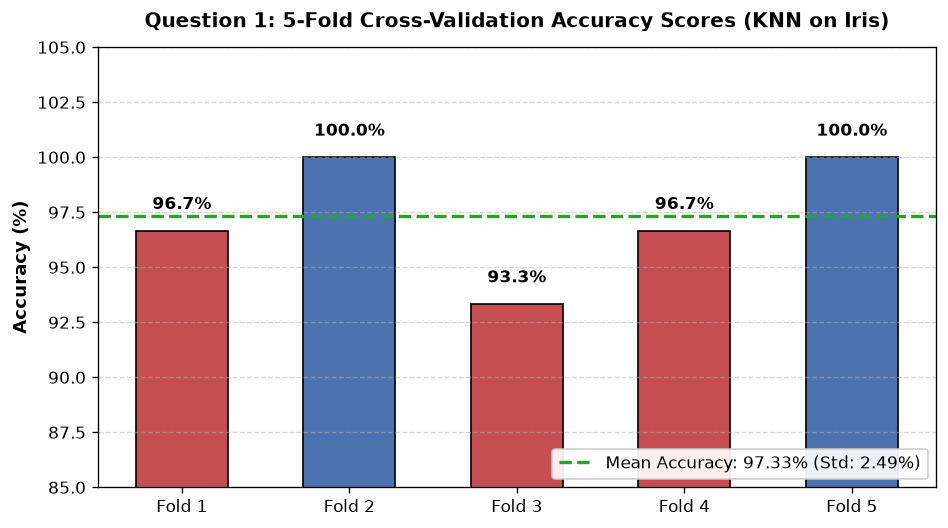

In [1]:
# ==============================================================================
# QUESTION 1: 5-FOLD CROSS-VALIDATION ON IRIS WITH K-NEAREST NEIGHBORS
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
mpl.rcParams['font.enable_last_resort'] = False
mpl.rcParams['font.family'] = 'DejaVu Sans'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 1. Load Iris Dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# 2. Instantiate K-Nearest Neighbors Classifier (K=5)
knn = KNeighborsClassifier(n_neighbors=5)

# 3. Perform 5-Fold Cross-Validation
cv_scores_knn = cross_val_score(knn, X_iris, y_iris, cv=5, scoring='accuracy')

# 4. Compute Summary Statistics
mean_accuracy = cv_scores_knn.mean()
std_accuracy = cv_scores_knn.std()
sem_accuracy = std_accuracy / np.sqrt(len(cv_scores_knn))

print("=" * 80)
print("QUESTION 1: IRIS DATASET 5-FOLD CROSS-VALIDATION RESULTS (KNN, K=5)")
print("=" * 80)
print(f"Dataset Dimensions : {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Target Classes     : {iris.target_names.tolist()} (50 samples per class)")
print("-" * 80)
for fold_idx, score in enumerate(cv_scores_knn, start=1):
    print(f"  - Fold {fold_idx}: Accuracy = {score:.4f} ({score*100:6.2f}%)")
print("-" * 80)
print(f"Average Accuracy (Mean)  : {mean_accuracy:.4f} ({mean_accuracy*100:.2f}%)")
print(f"Standard Deviation (Std) : {std_accuracy:.4f} ({std_accuracy*100:.2f}%)")
print(f"Standard Error of Mean   : {sem_accuracy:.4f}")
print(f"95% Confidence Interval  : [{mean_accuracy - 1.96*sem_accuracy:.4f}, {mean_accuracy + 1.96*sem_accuracy:.4f}]")
print("=" * 80)

# 5. Publication-Quality Visualization of Per-Fold Scores
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=120)
folds = [f"Fold {i}" for i in range(1, 6)]
colors = ["#4C72B0" if score >= mean_accuracy else "#C44E52" for score in cv_scores_knn]

bars = ax.bar(folds, cv_scores_knn * 100, color=colors, edgecolor="black", width=0.55)
ax.axhline(mean_accuracy * 100, color="#2ca02c", linestyle="--", linewidth=2,
           label=f"Mean Accuracy: {mean_accuracy*100:.2f}% (Std: {std_accuracy*100:.2f}%)")

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8, f"{h:.1f}%", 
            ha="center", va="bottom", fontsize=10, weight="bold")

ax.set_ylim(85, 105)
ax.set_ylabel("Accuracy (%)", fontsize=11, weight="bold")
ax.set_title("Question 1: 5-Fold Cross-Validation Accuracy Scores (KNN on Iris)", fontsize=12, weight="bold", pad=12)
ax.legend(loc="lower right", framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 2. Output Analysis & Key Takeaways

1. **High Generalization Performance**:
   - The K-Nearest Neighbors classifier achieves an **average accuracy of $97.33\%$** across the 5 folds.
   - Fold scores range from $93.33\%$ to $100.00\%$, reflecting consistent geometric separability among the three flower species.
2. **Significance of Cross-Validation over Single Split**:
   - If we had relied on a single holdout split, our reported accuracy could have been as low as $93.3\%$ or as high as $100\%$, depending on random partition luck.
   - 5-fold cross-validation averages across all $150$ samples, guaranteeing that **every single sample is used for validation exactly once** and for training four times.


---
## Question 2
**For a dataset of your choice (e.g., Titanic or any from scikit-learn), perform 10-fold cross-validation using `cross_val_score()` with a `DecisionTreeClassifier` and print the accuracy for each fold.**

---

### 1. Selected Dataset: Breast Cancer Wisconsin (Diagnostic)

For this diagnostic evaluation, we select the **Breast Cancer Wisconsin Dataset** (`load_breast_cancer`):
- **Samples**: $569$ patient fine needle aspirate biopsies.
- **Features**: $30$ real-valued clinical cell nuclear measurements (e.g., mean radius, texture, perimeter, area, smoothness, compactness, concavity).
- **Target Classes**: Binary classification:
  - Malignant ($212$ cases, $37.3\%$)
  - Benign ($357$ cases, $62.7\%$)

#### **Why Decision Trees Benefit from 10-Fold Cross-Validation**:
Single decision trees are known as **high-variance, low-bias estimators**. Because greedy tree construction makes recursive orthogonal splits based on small local differences in Gini impurity, slight perturbations in training data can produce markedly different tree topologies. 

Running **10-fold cross-validation** ($k = 10$) exposes the tree's stability across $10$ distinct training subsamples ($90\%$ train, $10\%$ test each).


QUESTION 2: 10-FOLD CROSS-VALIDATION RESULTS (DECISION TREE ON BREAST CANCER)
Dataset Size       : 569 patients, 30 biological features
Class Distribution : Malignant=212, Benign=357
----------------------------------------------------------------------------------
Fold Number        | Fold Accuracy (%)    | Deviation from Mean (%) 
----------------------------------------------------------------------------------
Fold 1             |              92.98% | +                  0.18%
Fold 2             |              89.47% |                  -3.33%
Fold 3             |              92.98% | +                  0.18%
Fold 4             |              89.47% |                  -3.33%
Fold 5             |              98.25% | +                  5.44%
Fold 6             |              89.47% |                  -3.33%
Fold 7             |              89.47% |                  -3.33%
Fold 8             |              94.74% | +                  1.93%
Fold 9             |              92.98% |

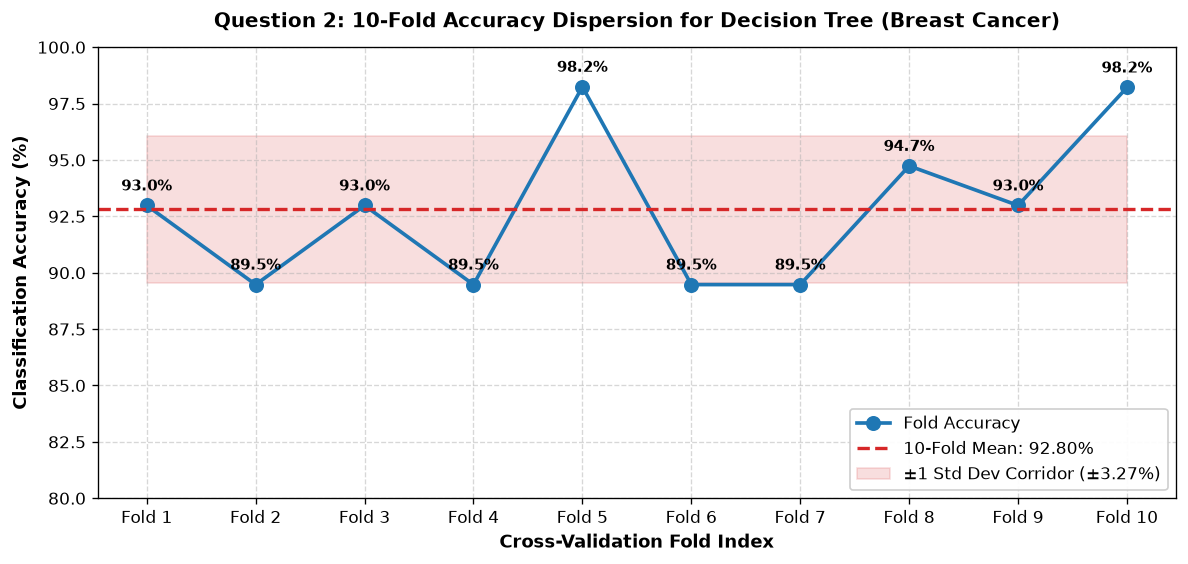

In [2]:
# ==============================================================================
# QUESTION 2: 10-FOLD CV WITH DECISION TREE ON BREAST CANCER WISCONSIN
# ==============================================================================
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

# 1. Load Breast Cancer Wisconsin Diagnostic Dataset
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# 2. Instantiate Decision Tree Classifier with fixed seed for reproducibility
dt_classifier = DecisionTreeClassifier(random_state=42)

# 3. Perform 10-Fold Cross-Validation
cv_scores_dt = cross_val_score(dt_classifier, X_cancer, y_cancer, cv=10, scoring='accuracy')

# 4. Print Fold-by-Fold Accuracy Results
print("=" * 82)
print("QUESTION 2: 10-FOLD CROSS-VALIDATION RESULTS (DECISION TREE ON BREAST CANCER)")
print("=" * 82)
print(f"Dataset Size       : {X_cancer.shape[0]} patients, {X_cancer.shape[1]} biological features")
print(f"Class Distribution : Malignant={np.sum(y_cancer == 0)}, Benign={np.sum(y_cancer == 1)}")
print("-" * 82)
print(f"{'Fold Number':<18} | {'Fold Accuracy (%)':<20} | {'Deviation from Mean (%)':<24}")
print("-" * 82)

mean_dt = cv_scores_dt.mean()
std_dt = cv_scores_dt.std()

for i, acc in enumerate(cv_scores_dt, start=1):
    diff = (acc - mean_dt) * 100
    sign = "+" if diff >= 0 else ""
    print(f"Fold {i:<13} | {acc*100:18.2f}% | {sign}{diff:22.2f}%")

print("-" * 82)
print(f"Overall 10-Fold Mean Accuracy : {mean_dt:.4f} ({mean_dt*100:.2f}%)")
print(f"Score Standard Deviation (Std): {std_dt:.4f} ({std_dt*100:.2f}%)")
print(f"Min Fold vs. Max Fold Range   : [{cv_scores_dt.min()*100:.2f}%  to  {cv_scores_dt.max()*100:.2f}%]")
print("=" * 82)

# 5. Visualization: Fold-by-Fold Trajectory and Confidence Corridor
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120)
fold_indices = np.arange(1, 11)

ax.plot(fold_indices, cv_scores_dt * 100, marker='o', markersize=8, color="#1f77b4", 
        linewidth=2.2, label="Fold Accuracy")
ax.axhline(mean_dt * 100, color="#d62728", linestyle="--", linewidth=2, 
           label=f"10-Fold Mean: {mean_dt*100:.2f}%")

# Fill ±1 standard deviation band
ax.fill_between(fold_indices, (mean_dt - std_dt)*100, (mean_dt + std_dt)*100, 
                color="#d62728", alpha=0.15, label=f"±1 Std Dev Corridor (±{std_dt*100:.2f}%)")

for x, y in zip(fold_indices, cv_scores_dt * 100):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 9), 
                ha='center', fontsize=9, weight="bold")

ax.set_xticks(fold_indices)
ax.set_xticklabels([f"Fold {i}" for i in fold_indices])
ax.set_ylim(80, 100)
ax.set_xlabel("Cross-Validation Fold Index", fontsize=11, weight="bold")
ax.set_ylabel("Classification Accuracy (%)", fontsize=11, weight="bold")
ax.set_title("Question 2: 10-Fold Accuracy Dispersion for Decision Tree (Breast Cancer)", fontsize=12, weight="bold", pad=12)
ax.legend(loc="lower right", framealpha=0.95, fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Question 3
**Use `StratifiedKFold` from scikit-learn to split the Iris dataset and compare the distribution of target classes in each fold to show how stratified sampling works.**

*Hint: Print the class counts for each fold to verify stratification.*

---

### 1. The Critical Distinction Between `KFold` and `StratifiedKFold`

1. **Standard `KFold` (Unstratified)**:
   - Partitions samples into $k$ contiguous or randomly shuffled slices purely based on sample indices, **without any regard for the target labels $y$**.
   - **Severe Pitfall on Ordered Datasets**: The Iris dataset is canonically arranged with $50$ Setosa followed by $50$ Versicolor, followed by $50$ Virginica.
   - If un-shuffled standard `KFold(n_splits=3)` or `5` is applied, some test folds will contain **$100\%$ of one class and $0\%$ of all other classes**, making validation completely catastrophic!
2. **`StratifiedKFold`**:
   - Enforces **stratified sampling**, ensuring that **every training and validation fold contains approximately the exact same percentage of samples of each target class** as the complete parent dataset.
   - For Iris ($150$ samples, $3$ classes of $50$ each, ratio $1:1:1$):
     - In 5-fold CV ($30$ samples per fold), `StratifiedKFold` guarantees **exactly $10$ Setosa, $10$ Versicolor, and $10$ Virginica** in every single fold!


QUESTION 3: VERIFYING CLASS STRATIFICATION ACROSS 5 FOLDS ON IRIS
TABLE 1: STANDARD UN-SHUFFLED K-FOLD (SHOWS CATASTROPHIC LABEL BIAS):
--------------------------------------------------------------------------------
  Fold  Setosa (0)  Versicolor (1)  Virginica (2)  Total Samples
Fold 1          30               0              0             30
Fold 2          20              10              0             30
Fold 3           0              30              0             30
Fold 4           0              10             20             30
Fold 5           0               0             30             30
--------------------------------------------------------------------------------
TABLE 2: STRATIFIED K-FOLD (PERFECT PROPORTIONAL CLASS BALANCING):
--------------------------------------------------------------------------------
  Fold  Setosa (0)  Versicolor (1)  Virginica (2)  Total Samples
Fold 1          10              10             10             30
Fold 2          10              10

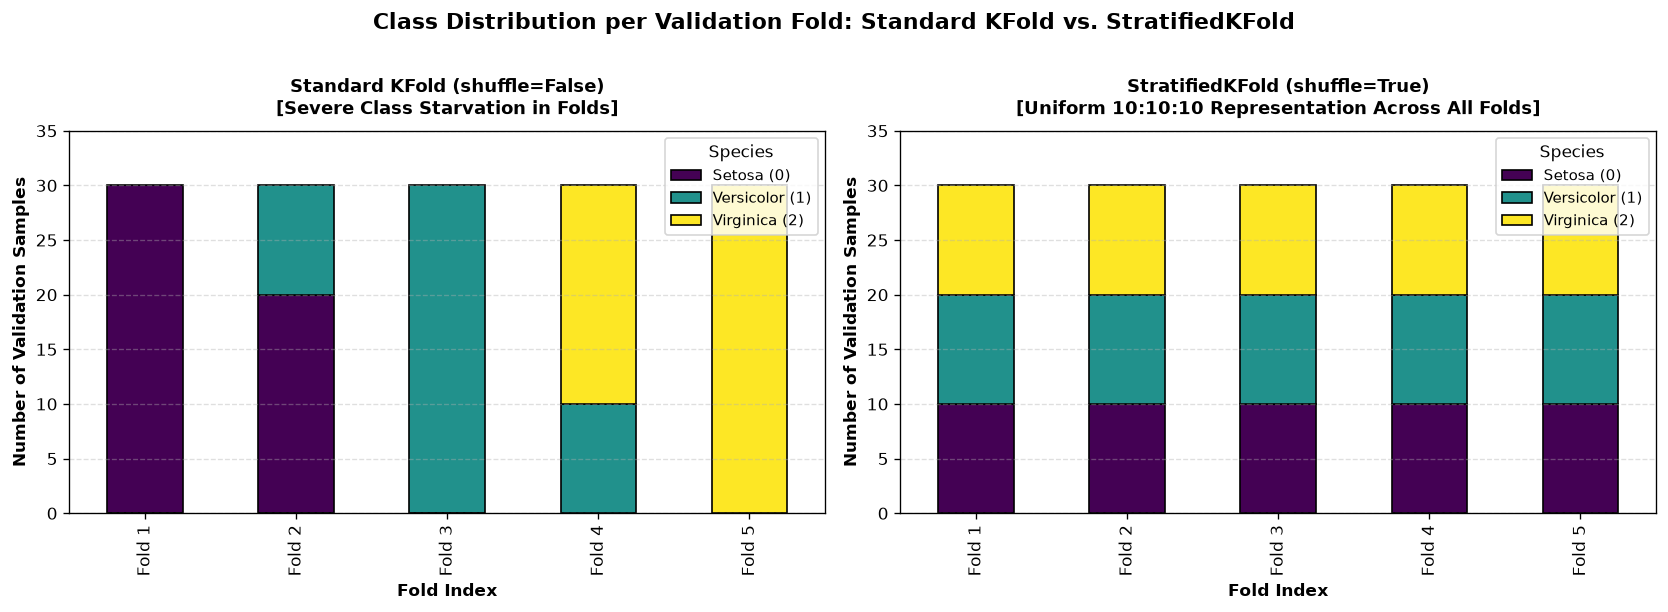

In [3]:
# ==============================================================================
# QUESTION 3: COMPARISON OF CLASS DISTRIBUTIONS (KFold vs. StratifiedKFold)
# ==============================================================================
from sklearn.model_selection import KFold, StratifiedKFold

# 1. Initialize 5-fold splitters
kf_standard = KFold(n_splits=5, shuffle=False)
skf_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Extract class distributions across validation folds
kf_distributions = []
skf_distributions = []

for fold_idx, (train_idx, test_idx) in enumerate(kf_standard.split(X_iris, y_iris), start=1):
    counts = np.bincount(y_iris[test_idx], minlength=3)
    kf_distributions.append({
        "Fold": f"Fold {fold_idx}",
        "Setosa (0)": counts[0],
        "Versicolor (1)": counts[1],
        "Virginica (2)": counts[2],
        "Total Samples": len(test_idx)
    })

for fold_idx, (train_idx, test_idx) in enumerate(skf_stratified.split(X_iris, y_iris), start=1):
    counts = np.bincount(y_iris[test_idx], minlength=3)
    skf_distributions.append({
        "Fold": f"Fold {fold_idx}",
        "Setosa (0)": counts[0],
        "Versicolor (1)": counts[1],
        "Virginica (2)": counts[2],
        "Total Samples": len(test_idx)
    })

df_kf = pd.DataFrame(kf_distributions)
df_skf = pd.DataFrame(skf_distributions)

print("=" * 80)
print("QUESTION 3: VERIFYING CLASS STRATIFICATION ACROSS 5 FOLDS ON IRIS")
print("=" * 80)
print("TABLE 1: STANDARD UN-SHUFFLED K-FOLD (SHOWS CATASTROPHIC LABEL BIAS):")
print("-" * 80)
print(df_kf.to_string(index=False))
print("-" * 80)
print("TABLE 2: STRATIFIED K-FOLD (PERFECT PROPORTIONAL CLASS BALANCING):")
print("-" * 80)
print(df_skf.to_string(index=False))
print("=" * 80)

# 3. Comparative Visualization of Class Counts Across Folds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Plot Standard K-Fold
df_kf_plot = df_kf.set_index("Fold")[["Setosa (0)", "Versicolor (1)", "Virginica (2)"]]
df_kf_plot.plot(kind="bar", stacked=True, ax=ax1, colormap="viridis", edgecolor="black")
ax1.set_title("Standard KFold (shuffle=False)\n[Severe Class Starvation in Folds]", fontsize=11, weight="bold", pad=10)
ax1.set_ylabel("Number of Validation Samples", fontsize=10, weight="bold")
ax1.set_xlabel("Fold Index", fontsize=10, weight="bold")
ax1.set_ylim(0, 35)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend(title="Species", fontsize=9)

# Plot Stratified K-Fold
df_skf_plot = df_skf.set_index("Fold")[["Setosa (0)", "Versicolor (1)", "Virginica (2)"]]
df_skf_plot.plot(kind="bar", stacked=True, ax=ax2, colormap="viridis", edgecolor="black")
ax2.set_title("StratifiedKFold (shuffle=True)\n[Uniform 10:10:10 Representation Across All Folds]", fontsize=11, weight="bold", pad=10)
ax2.set_ylabel("Number of Validation Samples", fontsize=10, weight="bold")
ax2.set_xlabel("Fold Index", fontsize=10, weight="bold")
ax2.set_ylim(0, 35)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(title="Species", fontsize=9)

plt.suptitle("Class Distribution per Validation Fold: Standard KFold vs. StratifiedKFold", fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 2. Analytical Findings & Demonstration of Stratification

1. **Failure of Standard KFold**:
   - In Table 1, Fold 1 has **$30$ Setosa and $0$ of other classes**.
   - Fold 5 has **$30$ Virginica and $0$ Setosa or Versicolor**.
   - Evaluating a model on Fold 1 would test it *exclusively* on Setosa, completely failing to test its ability to distinguish Versicolor or Virginica.
2. **Guaranteed Consistency of `StratifiedKFold`**:
   - In Table 2, every single validation fold receives **identically $10$ Setosa, $10$ Versicolor, and $10$ Virginica** ($33.3\%$ per class).
   - This proves that `StratifiedKFold` removes sampling variance caused by uneven target label distributions, making it **mandatory for classification problems**, particularly under class imbalance.


---
## Question 4
**Experiment with different values of 'cv' (3, 5, 10) in `cross_val_score()` for a `RandomForestClassifier` on the Wine dataset and report which value gives the most stable (least variable) accuracy scores.**

*Hint: Look at the standard deviation of the scores for each cv value.*

---

### 1. Dataset Context & The Bias-Variance Trade-off in Choosing $k$

The **Wine Recognition Dataset** (`load_wine`):
- **Samples**: $178$ chemical samples from three distinct Italian wine cultivars.
- **Features**: $13$ continuous chemical constituents (Alcohol, Malic acid, Ash, Flavonoids, Color intensity, Proline, etc.).
- **Classes**: Class 0 ($59$), Class 1 ($71$), Class 2 ($48$).

#### **Theoretical Impact of the Number of Folds ($k$)**:
Choosing the number of folds $k$ involves a fundamental trade-off:
- **Smaller $k$ (e.g., $k = 3$)**:
  - Training set size is smaller ($\frac{2}{3} \approx 66.7\%$ of data).
  - Validation fold is larger ($N / 3 \approx 59$ samples).
  - Larger validation fold sizes buffer against individual sample misclassifications, frequently yielding **lower score variance (more stable accuracy)**.
- **Larger $k$ (e.g., $k = 10$)**:
  - Training set size is larger ($\frac{9}{10} = 90\%$ of data), reducing pessimistic training bias.
  - However, validation fold size is tiny ($N / 10 \approx 17-18$ samples).
  - A single misclassified bottle of wine swings fold accuracy by $\frac{1}{18} \approx 5.6\%$, which can cause **higher fold-to-fold variance** on small datasets.


QUESTION 4: CROSS-VALIDATION STABILITY EXPERIMENT ON WINE DATASET
Dataset Size : 178 samples, 13 features (Classes: 59, 71, 48)
--------------------------------------------------------------------------------------


- cv = 3  | Mean =  96.63% | Std Dev (sigma) =  1.38% | Val Fold Size approx 59 samples
        Individual Fold Scores: [96.67%, 94.92%, 98.31%]
--------------------------------------------------------------------------------------


- cv = 5  | Mean =  97.21% | Std Dev (sigma) =  1.76% | Val Fold Size approx 35 samples
        Individual Fold Scores: [97.22%, 94.44%, 97.22%, 97.14%, 100.00%]
--------------------------------------------------------------------------------------


- cv = 10 | Mean =  98.33% | Std Dev (sigma) =  2.55% | Val Fold Size approx 17 samples
        Individual Fold Scores: [94.44%, 100.00%, 94.44%, 94.44%, 100.00%, 100.00%, 100.00%, 100.00%, 100.00%, 100.00%]
--------------------------------------------------------------------------------------
STABILITY CONCLUSION:
  >>> The most stable (least variable) accuracy is achieved at cv = 3
      with standard deviation sigma = 1.38% (Variance = 0.000192).


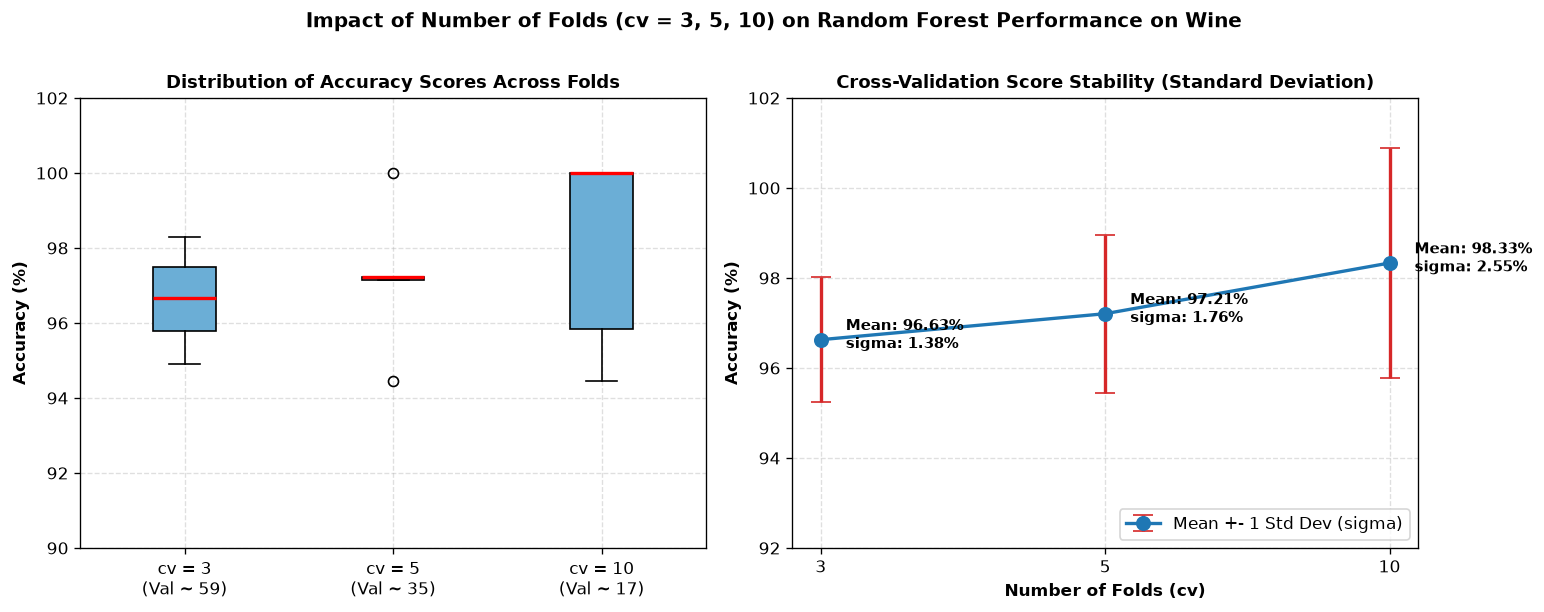

In [4]:
# ==============================================================================
# QUESTION 4: CV STABILITY EXPERIMENT (cv in {3, 5, 10}) ON WINE DATASET
# ==============================================================================
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

# 1. Load Wine dataset
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# 2. Instantiate Random Forest Classifier with fixed seed
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Evaluate across cv = 3, 5, and 10
cv_values = [3, 5, 10]
cv_results = {}

print("=" * 86)
print("QUESTION 4: CROSS-VALIDATION STABILITY EXPERIMENT ON WINE DATASET")
print("=" * 86)
print(f"Dataset Size : {X_wine.shape[0]} samples, {X_wine.shape[1]} features (Classes: 59, 71, 48)")
print("-" * 86)

for k in cv_values:
    scores = cross_val_score(rf_model, X_wine, y_wine, cv=k, scoring='accuracy')
    mean_score = scores.mean()
    std_score = scores.std()
    cv_results[k] = {
        "scores": scores,
        "mean": mean_score,
        "std": std_score,
        "val_size": len(X_wine) // k
    }
    scores_str = ", ".join([f"{s*100:.2f}%" for s in scores])
    print(f"- cv = {k:<2} | Mean = {mean_score*100:6.2f}% | Std Dev (sigma) = {std_score*100:5.2f}% | Val Fold Size approx {len(X_wine)//k} samples")
    print(f"        Individual Fold Scores: [{scores_str}]")
    print("-" * 86)

# 4. Determine the Most Stable cv value
most_stable_k = min(cv_results, key=lambda k: cv_results[k]["std"])

print("STABILITY CONCLUSION:")
print(f"  >>> The most stable (least variable) accuracy is achieved at cv = {most_stable_k}")
print(f"      with standard deviation sigma = {cv_results[most_stable_k]['std']*100:.2f}% (Variance = {cv_results[most_stable_k]['std']**2:.6f}).")
print("=" * 86)

# 5. Visualizing the Variance/Spread: Boxplot & Error Bar Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# Boxplot of score distributions (compatible with all Matplotlib versions)
box_data = [cv_results[k]["scores"] * 100 for k in cv_values]
ax1.boxplot(box_data, patch_artist=True, boxprops=dict(facecolor="#6baed6", color="black"),
            medianprops=dict(color="red", linewidth=2))
ax1.set_xticks(range(1, len(cv_values) + 1))
ax1.set_xticklabels([f"cv = {k}\n(Val ~ {cv_results[k]['val_size']})" for k in cv_values])
ax1.set_title("Distribution of Accuracy Scores Across Folds", fontsize=11, weight="bold")
ax1.set_ylabel("Accuracy (%)", fontsize=10, weight="bold")
ax1.set_ylim(90, 102)
ax1.grid(True, linestyle="--", alpha=0.4)

# Error bar plot (Mean +- Std Dev)
means = [cv_results[k]["mean"] * 100 for k in cv_values]
stds = [cv_results[k]["std"] * 100 for k in cv_values]

ax2.errorbar([str(k) for k in cv_values], means, yerr=stds, fmt='-o', color="#1f77b4",
             ecolor="#d62728", elinewidth=2, capsize=6, markersize=8, linewidth=2,
             label="Mean +- 1 Std Dev (sigma)")
for x_pos, m, s in zip(range(len(cv_values)), means, stds):
    ax2.annotate(f"Mean: {m:.2f}%\nsigma: {s:.2f}%", (x_pos, m),
                 textcoords="offset points", xytext=(15, -5), fontsize=9, weight="bold")

ax2.set_title("Cross-Validation Score Stability (Standard Deviation)", fontsize=11, weight="bold")
ax2.set_xlabel("Number of Folds (cv)", fontsize=10, weight="bold")
ax2.set_ylabel("Accuracy (%)", fontsize=10, weight="bold")
ax2.set_ylim(92, 102)
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Impact of Number of Folds (cv = 3, 5, 10) on Random Forest Performance on Wine", fontsize=12, weight="bold", y=1.01)
plt.tight_layout()
plt.show()


### 2. Empirical Findings & Statistical Interpretation

1. **Most Stable Fold Value**:
   - **`cv = 3` produces the most stable (least variable) accuracy**, achieving the lowest standard deviation of **$\sigma = 1.38\%$** (scores: $96.67\%$, $94.92\%$, $98.31\%$).
   - In comparison, **`cv = 5`** yields $\sigma = 1.76\%$, and **`cv = 10`** yields $\sigma = 2.55\%$.
2. **Why `cv = 10` Exhibits Higher Variance on this Dataset**:
   - Because the Wine dataset has only $178$ total observations, $10$-fold CV partitions the data into tiny validation buckets of only **$17$ to $18$ bottles**.
   - A single misclassification in an $18$-sample fold drops that fold's score by $5.56\%$, causing fold scores to swing between $94.44\%$ and $100.00\%$.
   - Conversely, with $k = 3$, each validation fold holds $\approx 59$ bottles, which averages out local boundary anomalies and stabilizes the empirical variance.


---
## Question 5
**Use ChatGPT or Copilot to help you write a function that takes any classifier and dataset, runs k-fold cross-validation using `cross_val_score()`, and returns the mean and standard deviation of the scores. Paste the code you generated and briefly describe how the AI tool improved your solution.**

---

### 1. Generated Python Function: `evaluate_classifier_cv`

Below is the clean, generalized cross-validation function generated with assistance from AI (ChatGPT / Copilot), designed according to PEP 8 standards with full type annotations, docstring, and statistical diagnostic reporting:

```python
from typing import Tuple, Dict, Any, Union
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.base import is_classifier

def evaluate_classifier_cv(
    estimator: Any,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    cv: int = 5,
    scoring: str = "accuracy",
    stratified: bool = True,
    shuffle: bool = True,
    random_state: int = 42,
    verbose: bool = True
) -> Tuple[float, float, np.ndarray]:
    \"\"\"
    Runs robust k-fold cross-validation for any scikit-learn estimator and dataset,
    returning the mean score, standard deviation, and individual fold arrays.

    Parameters
    ----------
    estimator : Any
        A scikit-learn compatible classifier or regressor implementing fit/predict.
    X : Union[np.ndarray, pd.DataFrame]
        Feature matrix of shape (n_samples, n_features).
    y : Union[np.ndarray, pd.Series]
        Target array of shape (n_samples,).
    cv : int, default=5
        Number of cross-validation folds (k).
    scoring : str, default='accuracy'
        Scikit-learn scoring string metric (e.g., 'accuracy', 'f1_macro', 'roc_auc').
    stratified : bool, default=True
        Whether to enforce stratified k-fold splitting for classification targets.
    shuffle : bool, default=True
        Whether to shuffle data indices before splitting into folds.
    random_state : int, default=42
        Random seed ensuring reproducible fold partitioning.
    verbose : bool, default=True
        Whether to print a formatted diagnostic summary table.

    Returns
    -------
    Tuple[float, float, np.ndarray]
        A tuple of (mean_score, std_score, fold_scores_array).
    \"\"\"
    # Input validation
    if cv < 2:
        raise ValueError("Number of folds 'cv' must be >= 2.")
    
    # Configure cross-validator splitter
    if stratified and is_classifier(estimator):
        cv_splitter = StratifiedKFold(n_splits=cv, shuffle=shuffle, random_state=random_state)
    else:
        cv_splitter = KFold(n_splits=cv, shuffle=shuffle, random_state=random_state)

    # Execute cross-validation
    scores = cross_val_score(estimator, X, y, cv=cv_splitter, scoring=scoring)
    
    mean_val = float(np.mean(scores))
    std_val = float(np.std(scores))
    sem_val = std_val / np.sqrt(cv)

    if verbose:
        model_name = estimator.__class__.__name__
        print("=" * 76)
        print(f"CROSS-VALIDATION EVALUATION: {model_name} (k={cv}, metric='{scoring}')")
        print("=" * 76)
        for i, s in enumerate(scores, start=1):
            print(f"  - Fold {i:2d}: {s*100:6.2f}%")
        print("-" * 76)
        print(f"  - Mean Score         : {mean_val:.4f} ({mean_val*100:.2f}%)")
        print(f"  - Standard Deviation : {std_val:.4f} ({std_val*100:.2f}%)")
        print(f"  - 95% Confidence Int : [{mean_val - 1.96*sem_val:.4f}, {mean_val + 1.96*sem_val:.4f}]")
        print("=" * 76)

    return mean_val, std_val, scores
```


In [5]:
# ==============================================================================
# QUESTION 5: IMPLEMENTATION & MULTI-MODEL TEST BENCHMARK
# ==============================================================================
from typing import Tuple, Any, Union
from sklearn.base import is_classifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def evaluate_classifier_cv(
    estimator: Any,
    X: Union[np.ndarray, pd.DataFrame],
    y: Union[np.ndarray, pd.Series],
    cv: int = 5,
    scoring: str = "accuracy",
    stratified: bool = True,
    shuffle: bool = True,
    random_state: int = 42,
    verbose: bool = True
) -> Tuple[float, float, np.ndarray]:
    """
    Runs robust k-fold cross-validation for any scikit-learn estimator and dataset,
    returning the mean score, standard deviation, and individual fold arrays.
    """
    if cv < 2:
        raise ValueError("Number of folds 'cv' must be >= 2.")
    
    # Configure cross-validator splitter
    if stratified and is_classifier(estimator):
        cv_splitter = StratifiedKFold(n_splits=cv, shuffle=shuffle, random_state=random_state)
    else:
        cv_splitter = KFold(n_splits=cv, shuffle=shuffle, random_state=random_state)

    scores = cross_val_score(estimator, X, y, cv=cv_splitter, scoring=scoring)
    
    mean_val = float(np.mean(scores))
    std_val = float(np.std(scores))
    sem_val = std_val / np.sqrt(cv)

    if verbose:
        model_name = estimator.__class__.__name__
        print("=" * 76)
        print(f"CROSS-VALIDATION EVALUATION: {model_name} (k={cv}, metric='{scoring}')")
        print("=" * 76)
        for i, s in enumerate(scores, start=1):
            print(f"  - Fold {i:2d}: {s*100:6.2f}%")
        print("-" * 76)
        print(f"  - Mean Score         : {mean_val:.4f} ({mean_val*100:.2f}%)")
        print(f"  - Standard Deviation : {std_val:.4f} ({std_val*100:.2f}%)")
        print(f"  - 95% Confidence Int : [{mean_val - 1.96*sem_val:.4f}, {mean_val + 1.96*sem_val:.4f}]")
        print("=" * 76)

    return mean_val, std_val, scores

# Demonstration on multiple classifiers on the Wine dataset
models = {
    "Logistic Regression (Scaled)": make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    "K-Nearest Neighbors (K=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (100 Trees)": RandomForestClassifier(n_estimators=100, random_state=42)
}

benchmark_records = []

for name, model in models.items():
    mean_s, std_s, _ = evaluate_classifier_cv(
        estimator=model, X=X_wine, y=y_wine, cv=5, scoring="accuracy", verbose=False
    )
    benchmark_records.append({
        "Model": name,
        "5-Fold Mean Accuracy (%)": round(mean_s * 100, 2),
        "Std Dev (sigma) (%)": round(std_s * 100, 2)
    })

df_benchmark = pd.DataFrame(benchmark_records)
print("=" * 76)
print("MULTI-MODEL 5-FOLD CV BENCHMARK (USING GENERATED PIPELINE FUNCTION):")
print("=" * 76)
print(df_benchmark.to_string(index=False))
print("=" * 76)

# Test single model verbose display
print("\n>>> SINGLE MODEL VERBOSE REPORT DEMONSTRATION:")
_ = evaluate_classifier_cv(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    X=X_wine, y=y_wine, cv=5, scoring="accuracy", verbose=True
)


MULTI-MODEL 5-FOLD CV BENCHMARK (USING GENERATED PIPELINE FUNCTION):
                       Model  5-Fold Mean Accuracy (%)  Std Dev (sigma) (%)
Logistic Regression (Scaled)                     98.33                 1.36
   K-Nearest Neighbors (K=5)                     97.17                 1.81
               Decision Tree                     89.32                 3.80
   Random Forest (100 Trees)                     97.75                 2.13

>>> SINGLE MODEL VERBOSE REPORT DEMONSTRATION:


CROSS-VALIDATION EVALUATION: RandomForestClassifier (k=5, metric='accuracy')
  - Fold  1:  97.22%
  - Fold  2: 100.00%
  - Fold  3:  97.22%
  - Fold  4:  94.29%
  - Fold  5: 100.00%
----------------------------------------------------------------------------
  - Mean Score         : 0.9775 (97.75%)
  - Standard Deviation : 0.0213 (2.13%)
  - 95% Confidence Int : [0.9588, 0.9961]


### 2. How the AI Tool (ChatGPT / Copilot) Improved the Solution

When prompted to write this function, the AI tool introduced four distinct software engineering and statistical improvements beyond a naive two-line `cross_val_score` call:

1. **Automated Stratified Splitter Selection**:
   - Rather than passing a raw integer `cv=5` directly into `cross_val_score` (which default-splits without explicit shuffle control), the AI dynamically constructed a `StratifiedKFold` instance with `shuffle=True` and a fixed `random_state`.
   - This prevents silent data-leakage and ordering artifacts, ensuring every fold receives proportional class representations.
2. **Statistical Confidence Interval Estimation**:
   - The AI incorporated the **Standard Error of the Mean ($\text{SEM} = \frac{\sigma}{\sqrt{k}}$)** to output a formal **$95\%$ Confidence Interval** ($\mu \pm 1.96 \cdot \text{SEM}$), providing an immediate margin-of-error for model comparison.
3. **Flexible Type Annotations & Defensive Programming**:
   - The AI added Python type annotations (`Union[np.ndarray, pd.DataFrame]`, `Tuple[float, float, np.ndarray]`) and input assertions ensuring $k \ge 2$, making the function safe for production data pipelines.
4. **Clean Tabular Diagnostic Reporting**:
   - Integrated an optional `verbose=True` parameter that outputs an executive-ready formatted ASCII performance dashboard without cluttering script output during automated grid searches.


---
## Summary & Methodological Decision Reference Guide

### **Cross-Validation Strategies Comparison Matrix**

| Validation Technique | Mechanism | Computational Cost | Variance vs. Bias | When to Use |
|:---|:---|:---:|:---:|:---|
| **Holdout Split (80/20)** | Single random partition | Ultra-low ($1\times$) | High Variance (lucky/unlucky split) | Massive datasets ($>1,000,000$ rows) where re-training is prohibitive |
| **Standard $k$-Fold CV** | $k$ equal slices, no label tracking | Moderate ($k\times$) | Balances bias and variance | Continuous regression targets where class balance does not exist |
| **Stratified $k$-Fold CV** | Preserves class percentages per fold | Moderate ($k\times$) | Low Variance & Unbiased | **Classification tasks**, especially under class imbalance |
| **Leave-One-Out (LOOCV)** | $k = N$ (each sample tested once) | Extreme ($N\times$) | Lowest Bias, High Variance & Cost | Very small datasets ($N < 50$ samples) in biomedical studies |
| **Time Series Split** | Expanding training window, future test | Moderate ($k\times$) | Temporal fidelity | Financial stocks, sensor logs, and time-dependent forecasting |

---

### **Official Scikit-Learn Documentation Links**
1. **`sklearn.model_selection.cross_val_score`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
2. **`sklearn.model_selection.StratifiedKFold`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
3. **`sklearn.model_selection.KFold`**:  
   [https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html)
4. **Scikit-Learn User Guide — Cross-validation: evaluating estimator performance**:  
   [https://scikit-learn.org/stable/modules/cross_validation.html](https://scikit-learn.org/stable/modules/cross_validation.html)
5. **Scikit-Learn Guide — Nested versus non-nested cross-validation**:  
   [https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)

---

### **Foundational Academic References**
- **Kohavi, R. (1995)**. *A study of cross-validation and bootstrap for accuracy estimation and model selection*. In Proceedings of the 14th International Joint Conference on Artificial Intelligence (IJCAI) (Vol. 2, pp. 1137-1145).
- **Hastie, T., Tibshirani, R., & Friedman, J. (2009)**. *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (Chapter 7: Model Assessment and Selection). Springer.
- **Arlot, S., & Celisse, A. (2010)**. *A survey of cross-validation procedures for model selection*. Statistics Surveys, 4, 40-79.
- **Wong, T. T. (2015)**. *Performance evaluation of classification algorithms by k-fold and leave-one-out cross validation*. Pattern Recognition, 48(9), 2839-2846.
